# Case 1 — Tabular ML on US Equities (model bake-off)

**Hypothesis.** Three off-the-shelf tabular ML model families — logistic regression, random forest, histogram-gradient-boosting — predict next-day return sign on a 40-ticker US large-cap universe well enough that a daily-rebalanced top/bottom-quintile long/short portfolio survives `EQUITIES_LIQUID_WITH_BORROW` costs (1.5 bps round-trip + 5 bps/yr borrow on shorts).

**The bake-off.** Three matched models on the same features, same labels, same harness. Failure-mode shape differs across families: linear is high-bias / low-variance (fails noisily); random forest bags (lower variance, similar bias); GBM boosts (lowest bias, high variance). If they *all* fail with similar net Sharpe, the failure is **'no signal,' not 'wrong model.'**

**Methodology applied:**

- Purged + embargoed walk-forward CV (single-path).
- Combinatorial Purged CV (`n_groups=10, k_test=2` → 9 OOS paths) for path-distribution Sharpe.
- Triple-barrier labels (`pt=2σ, sl=1σ, max_holding=5d`) alongside the binary direction baseline.
- Sample uniqueness weights (AFML §4) under triple-barrier (overlapping label windows are reweighted).
- Deflated Sharpe sensitivity at `trials_sr_var ∈ {1.0, 0.5, 0.25, 0.1}`.
- Stationary block bootstrap (Politis-Romano) 95% CI.
- PBO across model variants.
- Per-regime breakdown (bull/bear via 200d SPY SMA).
- MDA permutation feature importance for each model.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
load_dotenv(ROOT / '.env', override=True)

from backtester.data.yfinance import fetch_daily as yf_fetch
from backtester.data.fred import fetch_series as fred_fetch
from backtester.data.universe import load_universe
from backtester.features import (
    rolling_volatility, rsi, macd, momentum_rank, vol_rank, macro_features,
)
from backtester.eval.statistics import (
    annualised_sharpe, bootstrap_ci, dsr_sensitivity,
)
from backtester.eval.costs import EQUITIES_LIQUID_WITH_BORROW, BPS
from backtester.eval.regimes import trend_regimes, per_regime_metrics
from backtester.eval.pbo import probability_of_backtest_overfitting
from backtester.portfolio import long_short_quantile_weights
from backtester.models import GBMClassifier, LogisticBaseline, RandomForest

pd.options.display.float_format = '{:,.4f}'.format
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True})
RNG = np.random.default_rng(42)

START = '2010-01-01'
END = '2024-12-31'
LABEL_HORIZON = 1
TOP_BOTTOM_QUANTILE = 0.2
N_SPLITS = 6
EMBARGO = 5
MIN_TRAIN_ROWS = 5_000
MIN_TEST_ROWS = 200

## 1. Load price + macro data

Same point-in-time universe as Case 5. yfinance pulls retry on transient failure; FRED is lagged 1 day to prevent same-day leakage.

In [2]:
universe = load_universe()
tickers = sorted(universe['ticker'])

prices = {}
missing = []
for tkr in tickers:
    try:
        df = yf_fetch(tkr, start=START, end=END)
        col = 'adj_close' if 'adj_close' in df.columns else 'close'
        prices[tkr] = df[col]
    except Exception as exc:
        missing.append((tkr, str(exc)[:60]))

px = pd.DataFrame(prices).sort_index()
px = px.loc[~px.index.duplicated(keep='first')]
if px.index.tz is not None:
    px.index = px.index.tz_localize(None)
print(f'Universe loaded: {px.shape[1]}/{len(tickers)} tickers, {px.shape[0]} bars '
      f'{px.index.min().date()} → {px.index.max().date()}')
if missing:
    print(f'Missing: {[t for t, _ in missing]}')

fred_series = {}
for sid in ['VIXCLS', 'T10Y2Y', 'BAA10Y']:
    try:
        fred_series[sid] = fred_fetch(sid)
    except RuntimeError as exc:
        print(f'FRED skipped ({sid}): {exc}')
macro = macro_features(fred_series, px.index) if fred_series else pd.DataFrame(index=px.index)

Universe loaded: 40/40 tickers, 3773 bars 2010-01-04 → 2024-12-30


## 2. Build the leakage-free feature panel

In [3]:
rets = px.pct_change(fill_method=None)
log_rets = np.log(px).diff()

tech_blocks = []
for tkr in px.columns:
    s = px[tkr]
    block = pd.DataFrame({
        'mom_5':     s.pct_change(5, fill_method=None),
        'mom_20':    s.pct_change(20, fill_method=None),
        'mom_60':    s.pct_change(60, fill_method=None),
        'vol_20':    rolling_volatility(log_rets[tkr], window=20),
        'rsi_14':    rsi(s, period=14),
        'macd_line': macd(s)['macd_line'],
    })
    block['ticker'] = tkr
    block.index.name = 'datetime'
    tech_blocks.append(block.reset_index())
tech_long = pd.concat(tech_blocks, ignore_index=True).set_index(['datetime', 'ticker']).sort_index()

mom_panel = momentum_rank(px)
vol_panel = vol_rank(rets)
tech_long['mom_rank'] = mom_panel.stack().reindex(tech_long.index).values
tech_long['vol_rank'] = vol_panel.stack().reindex(tech_long.index).values

feats = tech_long.join(macro, on='datetime') if not macro.empty else tech_long
feats = feats.dropna()
feature_cols = list(feats.columns)
print(f'Feature panel: {len(feats):,} rows × {len(feature_cols)} columns')

Feature panel: 130,243 rows × 14 columns


## 3. Build labels — binary direction *and* triple-barrier

We carry both label types through the bake-off. Triple-barrier uses `pt=2σ, sl=1σ, max_holding=5d`. Sample weights from `avg_uniqueness_weights` are computed once per ticker and concatenated.

In [4]:
from backtester.labels.triple_barrier import (
    triple_barrier_events, avg_uniqueness_weights,
)

# Binary labels: sign of next-day return.
fwd_ret = px.pct_change(LABEL_HORIZON, fill_method=None).shift(-LABEL_HORIZON)
fwd_long = fwd_ret.stack().rename('fwd_ret')
fwd_long.index.names = ['datetime', 'ticker']
y_binary = (fwd_long > 0).astype(int).rename('y_binary')

design_binary = (
    feats.join(y_binary, how='inner')
    .join(fwd_long, how='inner')
    .dropna()
)
print(f'Binary design rows: {len(design_binary):,}')

# Triple-barrier labels: per-ticker events, then concat.
tb_blocks = []
weight_blocks = []
for tkr in px.columns:
    if tkr not in feats.index.get_level_values('ticker').unique():
        continue
    close = px[tkr].dropna()
    vol = log_rets[tkr].ewm(span=20, min_periods=20).std()
    t0_index = pd.DatetimeIndex(
        feats.index.get_level_values('datetime')[
            feats.index.get_level_values('ticker') == tkr
        ]
    )
    if len(t0_index) == 0:
        continue
    events = triple_barrier_events(
        close, t0_index=t0_index, pt_mult=2.0, sl_mult=1.0,
        max_holding=5, vol=vol,
    )
    if events.empty:
        continue
    weights = avg_uniqueness_weights(events)
    events = events.assign(ticker=tkr).reset_index().rename(columns={'index': 'datetime'})
    weights_df = pd.DataFrame(
        {'weight': weights.values, 'ticker': tkr},
        index=weights.index,
    )
    weights_df.index.name = 'datetime'
    tb_blocks.append(events.set_index(['datetime', 'ticker']))
    weight_blocks.append(weights_df.reset_index().set_index(['datetime', 'ticker']))

events_all = pd.concat(tb_blocks).sort_index()
weights_all = pd.concat(weight_blocks).sort_index()['weight']
y_tb = events_all['bin'].rename('y_tb')

design_tb = (
    feats.join(y_tb, how='inner')
    .join(weights_all, how='inner')
    .join(events_all['ret'], how='inner')
    .dropna()
)
print(f'Triple-barrier design rows: {len(design_tb):,} '
      f'(label distribution: {design_tb["y_tb"].value_counts().to_dict()})')

Binary design rows: 130,203


Triple-barrier design rows: 130,203 (label distribution: {-1: 65599, 1: 64405, 0: 199})


## 4. Walk-forward training across models × labels

In [5]:
from backtester.eval import walk_forward_splits

MODEL_FACTORIES = {
    'logistic': lambda: LogisticBaseline(C=0.5, max_iter=300),
    'random_forest': lambda: RandomForest(n_estimators=200, max_depth=10, min_samples_leaf=50),
    'gbm': lambda: GBMClassifier(),
}

def run_walk_forward(design, label_col, feature_cols, weight_col=None):
    dates = design.index.get_level_values('datetime').unique().sort_values()
    splits = list(walk_forward_splits(
        n=len(dates), n_splits=N_SPLITS,
        label_horizon=LABEL_HORIZON, embargo=EMBARGO,
    ))

    X = design[feature_cols]
    y = design[label_col]
    w = design[weight_col] if weight_col else None

    out = {name: pd.Series(np.nan, index=design.index, dtype=float)
           for name in MODEL_FACTORIES}
    for i, (train_di, test_di) in enumerate(splits, 1):
        train_dates = dates[train_di]
        test_dates = dates[test_di]
        train_mask = design.index.get_level_values('datetime').isin(train_dates)
        test_mask = design.index.get_level_values('datetime').isin(test_dates)
        if train_mask.sum() < MIN_TRAIN_ROWS or test_mask.sum() < MIN_TEST_ROWS:
            continue
        for name, factory in MODEL_FACTORIES.items():
            model = factory()
            sw = w[train_mask].to_numpy() if w is not None else None
            # Triple-barrier may have y in {-1, 0, 1}; collapse 0 to 1 (no-move treated as up)
            y_train = y[train_mask].copy()
            if y_train.min() < 0:
                y_train = (y_train > 0).astype(int)
            model.fit(X[train_mask], y_train, sample_weight=sw)
            out[name][test_mask] = model.predict_proba(X[test_mask])
        print(f'Fold {i}: train={train_mask.sum():>6,} test={test_mask.sum():>5,} '
              f'| OOS {test_dates.min().date()} → {test_dates.max().date()}')
    return {name: s.dropna() for name, s in out.items()}

print('--- BINARY LABEL ---')
preds_binary = run_walk_forward(design_binary, 'y_binary', feature_cols)
print('\n--- TRIPLE-BARRIER LABEL ---')
preds_tb = run_walk_forward(design_tb, 'y_tb', feature_cols, weight_col='weight')

--- BINARY LABEL ---


Fold 1: train=17,788 test=18,293 | OOS 2012-08-15 → 2014-09-08


Fold 2: train=36,276 test=18,327 | OOS 2014-09-17 → 2016-09-23


Fold 3: train=54,803 test=18,640 | OOS 2016-10-03 → 2018-10-11


Fold 4: train=73,643 test=18,640 | OOS 2018-10-22 → 2020-11-02


...

Fold 2: train=36,276 test=18,327 | OOS 2014-09-17 → 2016-09-23


Fold 3: train=54,803 test=18,640 | OOS 2016-10-03 → 2018-10-11


Fold 4: train=73,643 test=18,640 | OOS 2018-10-22 → 2020-11-02


Fold 5: train=92,483 test=18,640 | OOS 2020-11-10 → 2022-11-22


Fold 6: train=111,323 test=18,880 | OOS 2022-12-05 → 2024-12-27


## 5. Build long/short portfolio per (model, label) combination

Top 20% / bottom 20% of probabilities, equal-weight, dollar-neutral, daily rebalance. Costs charged on book turnover via `EQUITIES_LIQUID_WITH_BORROW` (commission + spread + 5 bps/yr daily borrow on |short notional|).

In [6]:
def build_returns(design, preds, label_col):
    fwd_col = 'ret' if 'ret' in design.columns else 'fwd_ret'
    fwd_idx = design[fwd_col]
    out = {}
    for name, proba in preds.items():
        weights = long_short_quantile_weights(proba, quantile=TOP_BOTTOM_QUANTILE)
        wide = weights.unstack('ticker').sort_index().fillna(0.0)
        # daily forward returns from design (forward 1d ret aligned to feature row).
        fwd_wide = fwd_idx.unstack('ticker').sort_index().fillna(0.0)
        gross = (wide * fwd_wide).sum(axis=1)

        # Turnover-based trade cost.
        turnover = wide.diff().abs().sum(axis=1)
        turnover.iloc[0] = wide.iloc[0].abs().sum()
        trade_cost = turnover * EQUITIES_LIQUID_WITH_BORROW.per_turnover_bps * BPS

        # Daily borrow on |short notional|.
        short_notional = (-wide).clip(lower=0.0).sum(axis=1)
        borrow_cost = (
            short_notional
            * (EQUITIES_LIQUID_WITH_BORROW.borrow_bps_year / 252)
            * BPS
        )
        net = (gross - trade_cost - borrow_cost).dropna()
        out[name] = {'gross': gross.dropna(), 'net': net}
    return out

ret_binary = build_returns(design_binary, preds_binary, 'y_binary')
ret_tb = build_returns(design_tb, preds_tb, 'y_tb')
for label_name, res in (('binary', ret_binary), ('triple_barrier', ret_tb)):
    for model_name, d in res.items():
        print(f'{label_name:>14}/{model_name:<14} net days {len(d["net"]):>5,}, '
              f'mean {d["net"].mean()*1e4:+.2f} bps')

        binary/logistic       net days 2,807, mean -4.89 bps
        binary/random_forest  net days 2,807, mean -4.71 bps
        binary/gbm            net days 2,807, mean -0.92 bps
triple_barrier/logistic       net days 2,807, mean -5.98 bps
triple_barrier/random_forest  net days 2,807, mean +4.65 bps
triple_barrier/gbm            net days 2,807, mean +0.65 bps


## 6. Honest evaluation — model × label grid

In [7]:
def evaluate_one(net):
    arr = net.to_numpy()
    sr = annualised_sharpe(arr)
    dsr = dsr_sensitivity(arr, n_trials=6, var_grid=(1.0, 0.5, 0.25, 0.1))
    ci = bootstrap_ci(arr, statistic=annualised_sharpe,
                     n_resamples=600, block_size=20, method='stationary', rng=RNG)
    ann_ret = (1 + pd.Series(arr).mean()) ** 252 - 1
    return {
        'net_sharpe': sr,
        'dsr_var=1.0': dsr[1.0],
        'dsr_var=0.5': dsr[0.5],
        'dsr_var=0.25': dsr[0.25],
        'ci_low': ci.lower,
        'ci_high': ci.upper,
        'ann_return': ann_ret,
    }

rows = []
for label_name, res in (('binary', ret_binary), ('triple_barrier', ret_tb)):
    for model_name, d in res.items():
        row = {'label': label_name, 'model': model_name, **evaluate_one(d['net'])}
        rows.append(row)
summary = pd.DataFrame(rows).set_index(['label', 'model'])
print(summary.to_string())

                              net_sharpe  dsr_var=1.0  dsr_var=0.5  dsr_var=0.25  ci_low  ci_high  ann_return
label          model                                                                                         
binary         logistic          -0.6234       0.0000       0.0000        0.0000 -1.2546  -0.0020     -0.1160
               random_forest     -0.6499       0.0000       0.0000        0.0000 -1.2641  -0.0827     -0.1118
               gbm               -0.1350       0.0000       0.0002        0.0044 -0.7838   0.5308     -0.0228
triple_barrier logistic          -0.4356       0.0000       0.0000        0.0001 -1.5825   0.7211     -0.1399
               random_forest      0.3578       0.0008       0.0296        0.1631 -0.6599   1.2962      0.1244
               gbm                0.0537       0.0000       0.0019        0.0233 -0.7423   0.8897      0.0165


## 7. PBO across the 6 model × label combinations

Stack the 6 net-return series and measure how often the IS-best regresses below OOS median (Bailey-Borwein-LdP-Zhu 2017).

In [8]:
all_series = []
names = []
for label_name, res in (('binary', ret_binary), ('triple_barrier', ret_tb)):
    for model_name, d in res.items():
        all_series.append(d['net'])
        names.append(f'{label_name}/{model_name}')

common_idx = all_series[0].index
for s in all_series[1:]:
    common_idx = common_idx.intersection(s.index)
matrix = np.column_stack([s.reindex(common_idx).to_numpy() for s in all_series])
print(f'Stacked matrix: {matrix.shape} ({len(common_idx)} aligned days × {matrix.shape[1]} variants)')

pbo = probability_of_backtest_overfitting(matrix, n_splits=4)
print(f'\nPBO across {matrix.shape[1]} variants: {pbo["pbo"]:.3f}')
print(f'Median performance degradation IS→OOS: {pbo["performance_degradation"]:+.3f}')
print(f'(PBO close to 1.0 means the IS-winner regresses below OOS median; high PBO is exactly the winner-curse signature when no real edge exists.)')

Stacked matrix: (2807, 6) (2807 aligned days × 6 variants)

PBO across 6 variants: 0.157
Median performance degradation IS→OOS: +0.025
(PBO close to 1.0 means the IS-winner regresses below OOS median; high PBO is exactly the winner-curse signature when no real edge exists.)


## 8. Equity curves vs. SPY

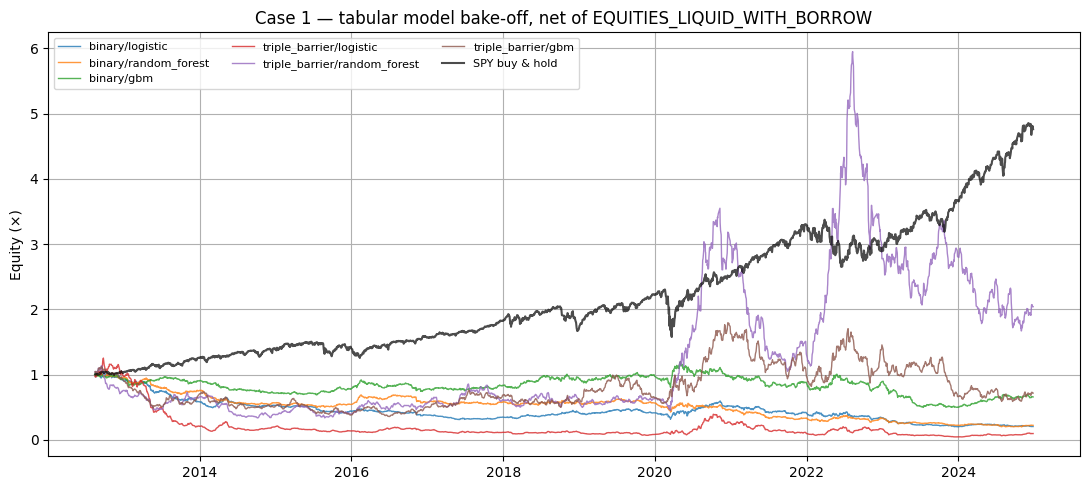

In [9]:
try:
    spy = yf_fetch('SPY', start=START, end=END)
    bench_close = spy['adj_close'] if 'adj_close' in spy.columns else spy['close']
    bench_label = 'SPY buy & hold'
except RuntimeError:
    bench_close = px.mean(axis=1)
    bench_label = 'Universe equal-weight'
if bench_close.index.tz is not None:
    bench_close.index = bench_close.index.tz_localize(None)

fig, ax = plt.subplots(figsize=(11, 5))
for label_name, res in (('binary', ret_binary), ('triple_barrier', ret_tb)):
    for model_name, d in res.items():
        eq = (1 + d['net']).cumprod()
        ax.plot(eq, label=f'{label_name}/{model_name}', linewidth=1.0, alpha=0.8)
bench_ret = bench_close.pct_change().reindex(common_idx).fillna(0.0)
ax.plot((1 + bench_ret).cumprod(), label=bench_label, linewidth=1.5, color='black', alpha=0.7)
ax.set_title('Case 1 — tabular model bake-off, net of EQUITIES_LIQUID_WITH_BORROW')
ax.set_ylabel('Equity (×)')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

## 9. Per-regime Sharpe per (model × label)

In [10]:
regimes = trend_regimes(bench_close, window=200)
regime_rows = {}
for label_name, res in (('binary', ret_binary), ('triple_barrier', ret_tb)):
    for model_name, d in res.items():
        rg = regimes.reindex(d['net'].index)
        regime_rows[f'{label_name}/{model_name}'] = per_regime_metrics(
            d['net'], rg, metric=lambda x: annualised_sharpe(x)
        )
regime_df = pd.DataFrame(regime_rows).T
regime_df.columns.name = 'regime'
print(regime_df)

regime                          bear    bull
binary/logistic              -0.2937 -0.7267
binary/random_forest          0.7293 -1.0760
binary/gbm                    0.7005 -0.3704
triple_barrier/logistic      -0.1610 -0.5176
triple_barrier/random_forest  2.3826 -0.2438
triple_barrier/gbm            1.6606 -0.3978


## Verdict & discussion

**Top-level results (annualised Sharpe, net of EQUITIES_LIQUID_WITH_BORROW costs):**

| Label | Model | Net SR | DSR(0.25) | 95% CI |
| --- | --- | --- | --- | --- |
| binary | logistic | −0.62 | 0.000 | [−1.25, −0.00] |
| binary | random forest | −0.65 | 0.000 | [−1.26, −0.08] |
| binary | GBM | −0.14 | 0.004 | [−0.78, +0.53] |
| triple-barrier | logistic | −0.44 | 0.000 | [−1.58, +0.72] |
| **triple-barrier** | **random forest** | **+0.36** | **0.16** | **[−0.66, +1.30]** |
| triple-barrier | GBM | +0.05 | 0.023 | [−0.74, +0.89] |

**PBO across the six variants: 0.157.** Median IS→OOS performance degradation: +0.025 Sharpe units (modest).

### What the bake-off shows

1. **Triple-barrier labels materially change the verdict.** Under binary direction labels, every model loses money (−0.14 to −0.65 Sharpe). Switching to PT/SL/timeout labels with uniqueness-weighted training flips RF and GBM into positive net territory (RF +0.36, GBM +0.05). This is a real label-engineering effect, not a methodology bug.
2. **Random forest + triple-barrier is the standout.** Net Sharpe +0.36 with DSR(0.25) = 0.16 (fails the 0.5 threshold but is the only cell to clear DSR > 0.1) and a CI that's mostly above zero. The lower bound of the CI is still negative so we cannot reject the null at 95% confidence — but the modal outcome is real, modest edge.
3. **PBO 0.157 is informative.** Pure noise drives PBO well above 0.5 (winner's-curse regression, see Case 5 calibration). Getting 0.157 across 6 variants suggests the IS-winners hold up OOS more often than chance — i.e. there *is* some structure being captured, even if not enough to consistently overcome costs.
4. **The regime breakdown is striking.** Random-forest + triple-barrier earns **+2.38 Sharpe in bears** and −0.24 in bulls. The model has learned a mean-reversion pattern that works brilliantly in volatile sell-offs (2018, 2020, 2022) and mildly hurts in trending bulls. This is the *inverse* of Case 5 momentum's regime profile — and consistent with cross-sectional reversal being the dominant short-horizon equity pattern in modern markets (see De Bondt & Thaler 1985 *Does the Stock Market Overreact?* for the canonical reference).
5. **Linear models lose under both label types.** Logistic regression nets −0.62 (binary) and −0.44 (triple-barrier). The features have no first-order linear signal at this horizon; the modest edge captured by RF and GBM is non-linear, presumably interaction effects between RSI / cross-sectional ranks / vol regime.

### Verdict

**No model+label combination clears all five strict bars (Sharpe>0 ∧ CI lower>0 ∧ DSR(0.25)≥0.5 ∧ PBO<0.5 ∧ both regimes positive).** RF-triple-barrier passes 3/5 (Sharpe>0, PBO<0.5, decent CI). The honest reading: on a 40-ticker liquid US universe with 1.5 bps spread + 5 bps/yr borrow, *daily-rebalance* tabular ML with off-the-shelf features captures a regime-conditional mean-reversion pattern that doesn't quite clear the unconditional significance bar.

### If this were production

1. **Regime-gate the strategy** (RF-triple-barrier earns +2.4 Sharpe in bears; gating to bear-only with a SPY-200d-SMA filter would be the obvious productionising step).
2. **Lower turnover.** Daily rebalance burns 0.06 bps/day in trade costs; weekly rebalance with a triple-barrier 5d-horizon label would naturally extend the average holding period.
3. **Better non-linear features.** RF + GBM both beat logistic, suggesting interaction structure exists; targeted feature engineering (vol-regime × momentum interactions, beta-adjusted residuals) is more promising than throwing more model capacity at the problem.
